In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat
import pickle
import torch

from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from utils_clique import (
    neuron_inf_dict_to_dataframe,
    get_recording_clique,
    plot_cliques,
    prepare_training_data,
    train_autosort_model,
    build_sliding_cliques,
    SimpleAutoSort,
    calibration_model,
    real_time_classifier
)
from scipy.io import loadmat

probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y
probe_position['chan_map'] = probe_data['chanMap0ind'].astype(int)

chan_map = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
merged = chan_map.merge(probe_position, left_on='probeloc', right_on='chan_map')\
                 .iloc[chan_map.index]\
                 .reset_index(drop=True)

probe = Probe()
probe.set_contacts(positions=merged.iloc[:, 2:4])
probe.set_device_channel_indices(range(256))

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
recording_raw = se.read_intan(f"/home/ubuntu/Documents/jct/project/251205/M190011_260121_150111_merged_130.rhd", stream_id= '0', ignore_integrity_checks=True)

print('read success')

recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)

recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

rec_params_raw = pd.read_csv("/media/ubuntu/sda/duan/result/260121/rec_params.csv")
rec_params_raw = rec_params_raw[rec_params_raw['bhv_codes'] == 10]

original_fs = 30000
target_fs = 10000
fs_ratio = original_fs / target_fs
rec_params_raw['rec_codes_points_10000'] = (rec_params_raw['rec_codes_points'] / fs_ratio).astype(int)
rec_params_raw = rec_params_raw[(rec_params_raw['trial_ids'] >= 300) & (rec_params_raw['trial_ids'] < 5300)]
start_sample = rec_params_raw['rec_codes_points_10000'].iloc[0]
end_sample = rec_params_raw['rec_codes_points_10000'].iloc[-1]

recording_segment = recording_f.frame_slice(start_frame=start_sample, end_frame=end_sample)
#recording_segment = recording_segment.save(format="binary", n_jobs = 30)   


read success


In [4]:
output_folder = '/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/'
probe.set_contact_ids(recording_segment.channel_ids)

cliques = build_sliding_cliques(
    probe,
    clique_size=32,
    min_size=25,
    min_overlap=6,
    target_groups=10,
)

clique_info = {
    'cliques': cliques,  # List of CliqueInfo objects
    'clique_params': {
        'clique_size': 32,
        'min_size': 25,
        'min_overlap': 6,
        'target_groups': 10,
    },
    'probe_df': probe.to_dataframe(),  # Probe dataframe for verification
}

clique_info_path = f'{output_folder}/clique_info.pkl'
with open(clique_info_path, 'wb') as f:
    pickle.dump(clique_info, f)

plot_cliques(probe, cliques, f'{output_folder}/cliques.pdf')

[INFO] Built 10 cliques (target 10)
       Clique 00: channels 204-39 (32 channels)
       Clique 01: channels 74-81 (32 channels)
       Clique 02: channels 174-227 (32 channels)
       Clique 03: channels 33-88 (32 channels)
       Clique 04: channels 69-253 (32 channels)
       Clique 05: channels 229-232 (32 channels)
       Clique 06: channels 35-24 (32 channels)
       Clique 07: channels 207-141 (32 channels)
       Clique 08: channels 134-109 (32 channels)
       Clique 09: channels 148-115 (32 channels)

Clique可视化PDF已保存至: /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//cliques.pdf


In [ ]:
neuron_inf_path = f'/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/clique_0/neuron_inf_all.pickle'

with open(neuron_inf_path, 'rb') as f:
    neuron_inf_dict = pickle.load(f)
neuron_inf = neuron_inf_dict_to_dataframe(neuron_inf_dict)


In [ ]:
output_folder = '/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/'

response_matrices_all_cliques = {}

for clique in cliques:
    clique_id = clique.clique_id
    print(f"\n{'='*60}")
    print(f"Processing Clique {clique_id}")
    print(f"{'='*60}")

    data_folder = f'{output_folder}/clique_{clique_id}'
    neuron_inf_path = f'{data_folder}/neuron_inf_all.pickle'

    with open(neuron_inf_path, 'rb') as f:
        neuron_inf_dict = pickle.load(f)

    neuron_inf = neuron_inf_dict_to_dataframe(neuron_inf_dict)
    print(f"\nSession: {len(neuron_inf)} 个神经元")

    probe_to_clique_index = {}
    recording_channel_ids = recording_segment.get_channel_ids()
    for clique_idx, probe_ch in enumerate(recording_channel_ids):
        probe_to_clique_index[str(probe_ch)] = clique_idx

    test_recording_clique = get_recording_clique(recording_segment, clique)
    print(f"  Recording通道数: {len(test_recording_clique.get_channel_ids())}")

    # 按照训练时的方式构建 probe_to_clique_index
    recording_channel_ids = test_recording_clique.get_channel_ids()
    probe_to_clique_index = {str(ch_id): idx for idx, ch_id in enumerate(recording_channel_ids)}

    detect_channel = {-1: [], 1: []}
    for _, row in neuron_inf.iterrows():
        extremum_channel = str(row['extremum_channel'])
        if extremum_channel in probe_to_clique_index:
            clique_idx = probe_to_clique_index[extremum_channel]
            sign = row.get('sign', None)
            if sign is None:
                template = row.get('template', None)
                if template is not None and isinstance(template, dict) and len(template) > 0:
                    sign = 1 if max(template.values()) > abs(min(template.values())) else -1
                else:
                    sign = -1
            detect_channel[sign].append(clique_idx)
    detect_channel[1] = list(set(detect_channel[1]))
    detect_channel[-1] = list(set(detect_channel[-1]))
    print(f"  正极性通道数: {len(detect_channel[1])}")
    print(f"  负极性通道数: {len(detect_channel[-1])}")

    test_recording_clique = get_recording_clique(recording_segment, clique)
    print(f"  Recording通道数: {len(test_recording_clique.get_channel_ids())}")

    model_save_dir = f'{data_folder}/model_1'
    n_channels = test_recording_clique.get_num_channels()
    samplepoints = 30
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    noise_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_noise_clsfier.pth'
    label_model_path = f'{model_save_dir}/multitask_single_wave_clsfier_label_clsfier.pth'
    classification_mapping_path = f'{model_save_dir}/classification_mapping.pkl'
    with open(classification_mapping_path, 'rb') as f:
        classification_mapping = pickle.load(f)
    keep_id_list = classification_mapping['label_list']
    autosort_model = SimpleAutoSort(
        ch_num=n_channels,
        samplepoints=samplepoints,
        device=device,
        set_shank_id=keep_id_list,
        save_dir=model_save_dir,
        pos_weight_noise=None,
        pos_weight_label=None
    )
    autosort_model.clsfier_noise.load_state_dict(torch.load(noise_model_path, map_location=device))
    autosort_model.clsfier_label.load_state_dict(torch.load(label_model_path, map_location=device))
    autosort_model.eval()

    all_neuron_ids = sorted(classification_mapping['label_to_unit'].values())
    n_neurons = len(all_neuron_ids)
    neuron_to_idx = {nid: i for i, nid in enumerate(all_neuron_ids)}
    rec_params_4000 = rec_params_raw.reset_index(drop=True).head(4000)
    n_trials = len(rec_params_4000)
    n_time_bins_ms = 600
    window_samples = 6000
    sample_to_ms = 0.1
    print(f"  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)")
    all_trial_raster_matrix = np.zeros((n_trials, n_neurons, n_time_bins_ms), dtype=np.float32)
    for trial_idx in tqdm(range(n_trials), desc="Trials"):
        stim_point = int(rec_params_4000['rec_codes_points_10000'].iloc[trial_idx])
        start_i = stim_point - 1500
        end_i = stim_point + 4500
        recording_trial = recording_f.frame_slice(start_frame=start_i, end_frame=end_i)
        test_recording_trial = get_recording_clique(recording_trial, clique)
        spiketrain_i = real_time_classifier(
            recording_f=test_recording_trial,
            autosort_model=autosort_model,
            start_frame=0,
            end_frame=window_samples,
            id_to_neuron=classification_mapping['label_to_unit'],
            detection_params={'thr_min': 5, 'thr_max': 35, 'distance': 3, 'wlen': 5, 'prominence': 15},
            window_params={'left_sample': 10, 'right_sample': 20},
            detect_channel=detect_channel,
            device=device,
            verbose=False
        )
        for unit_id, times in spiketrain_i.items():
            if unit_id not in neuron_to_idx:
                continue
            ni = neuron_to_idx[unit_id]
            for t in times:
                bin_idx = int(np.floor(t * sample_to_ms))
                if 0 <= bin_idx < n_time_bins_ms:
                    all_trial_raster_matrix[trial_idx, ni, bin_idx] += 1
    psth_window_size_ms = 20
    all_trial_psth_matrix = np.zeros((n_trials, n_neurons, n_time_bins_ms), dtype=np.float32)
    for time_point_ms in range(n_time_bins_ms):
        if time_point_ms - psth_window_size_ms // 2 < 0:
            window_start_ms = 0
            window_end_ms = psth_window_size_ms
        elif time_point_ms + psth_window_size_ms // 2 + 1 > n_time_bins_ms:
            window_start_ms = n_time_bins_ms - psth_window_size_ms
            window_end_ms = n_time_bins_ms
        else:
            window_start_ms = time_point_ms - psth_window_size_ms // 2
            window_end_ms = time_point_ms + psth_window_size_ms // 2 + 1
        time_window = np.arange(window_start_ms, window_end_ms)
        all_trial_psth_matrix[:, :, time_point_ms] = 1000 * np.sum(all_trial_raster_matrix[:, :, time_window], axis=2) / len(time_window)
    n_bins_target = 30
    gaussian_sigma_bins = 10
    n_time_bins = all_trial_psth_matrix.shape[2]
    neuron_trial_response = np.zeros((n_neurons, n_trials, n_time_bins), dtype=np.float32)
    for neur in range(n_neurons):
        neuron_trial_response[neur, :, :] = all_trial_psth_matrix[:, neur, :]
    neuron_trial_response = gaussian_filter1d(
        neuron_trial_response, sigma=gaussian_sigma_bins, axis=2, mode="nearest"
    )
    bin_size = n_time_bins // n_bins_target
    n_valid = n_bins_target * bin_size
    neuron_trial_response = (
        neuron_trial_response[:, :, :n_valid]
        .reshape(n_neurons, n_trials, n_bins_target, bin_size)
        .mean(axis=-1)
    )
    response_matrix_path = f"{data_folder}/response_matrix_4000trials_30bins.pkl"
    with open(response_matrix_path, 'wb') as f:
        pickle.dump({'response_matrix': neuron_trial_response, 'neuron_ids': all_neuron_ids}, f)
    print(f"  响应矩阵形状: {neuron_trial_response.shape} (n_neurons, n_trials, 30), 已保存至 {response_matrix_path}")
    response_matrices_all_cliques[clique_id] = {
        'response_matrix': neuron_trial_response,
        'neuron_ids': all_neuron_ids,
    }

print("\n所有测试完成！")
print(f"所有 clique 的响应矩阵: response_matrices_all_cliques, 共 {len(response_matrices_all_cliques)} 个 clique")
print("每个 key 为 clique_id，value 为 {'response_matrix': (n_neurons, 4000, 30), 'neuron_ids': list}")


Processing Clique 0

Session: 46 个神经元
  Recording通道数: 32
  正极性通道数: 8
  负极性通道数: 26
  Recording通道数: 32
  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)


Trials: 100%|██████████| 4000/4000 [10:55<00:00,  6.10it/s]


  响应矩阵形状: (46, 4000, 30) (n_neurons, n_trials, 30), 已保存至 /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_0/response_matrix_4000trials_30bins.pkl

Processing Clique 1

Session: 42 个神经元
  Recording通道数: 32
  正极性通道数: 12
  负极性通道数: 21
  Recording通道数: 32
  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)


Trials: 100%|██████████| 4000/4000 [10:54<00:00,  6.11it/s]


  响应矩阵形状: (42, 4000, 30) (n_neurons, n_trials, 30), 已保存至 /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_1/response_matrix_4000trials_30bins.pkl

Processing Clique 2

Session: 46 个神经元
  Recording通道数: 32
  正极性通道数: 19
  负极性通道数: 24
  Recording通道数: 32
  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)


...

  响应矩阵形状: (32, 4000, 30) (n_neurons, n_trials, 30), 已保存至 /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_7/response_matrix_4000trials_30bins.pkl

Processing Clique 8

Session: 23 个神经元
  Recording通道数: 32
  正极性通道数: 13
  负极性通道数: 7
  Recording通道数: 32
  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)


Trials: 100%|██████████| 4000/4000 [10:59<00:00,  6.06it/s]


  响应矩阵形状: (23, 4000, 30) (n_neurons, n_trials, 30), 已保存至 /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_8/response_matrix_4000trials_30bins.pkl

Processing Clique 9

Session: 48 个神经元
  Recording通道数: 32
  正极性通道数: 13
  负极性通道数: 15
  Recording通道数: 32
  4000 trials: 每个 trial 单独运行 real_time_classifier (600ms 窗)


Trials: 100%|██████████| 4000/4000 [10:43<00:00,  6.22it/s]


  响应矩阵形状: (35, 4000, 30) (n_neurons, n_trials, 30), 已保存至 /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_9/response_matrix_4000trials_30bins.pkl

所有测试完成！
所有 clique 的响应矩阵: response_matrices_all_cliques, 共 10 个 clique
每个 key 为 clique_id，value 为 {'response_matrix': (n_neurons, 4000, 30), 'neuron_ids': list}


选中 trials: [4778 4779 4780 4781 4782]
刺激时间点 (samples): 34707935 - 34737102
时间窗: 从 trial 4477 前 300ms 到 trial 4481 后 600ms
总时间窗长度: 38167 samples = 3816.7 ms

处理 Clique 0...
  PDF 已保存: /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//clique_0/raster_trace_trials_4477_4481.pdf

处理 Clique 1...


KeyboardInterrupt: 

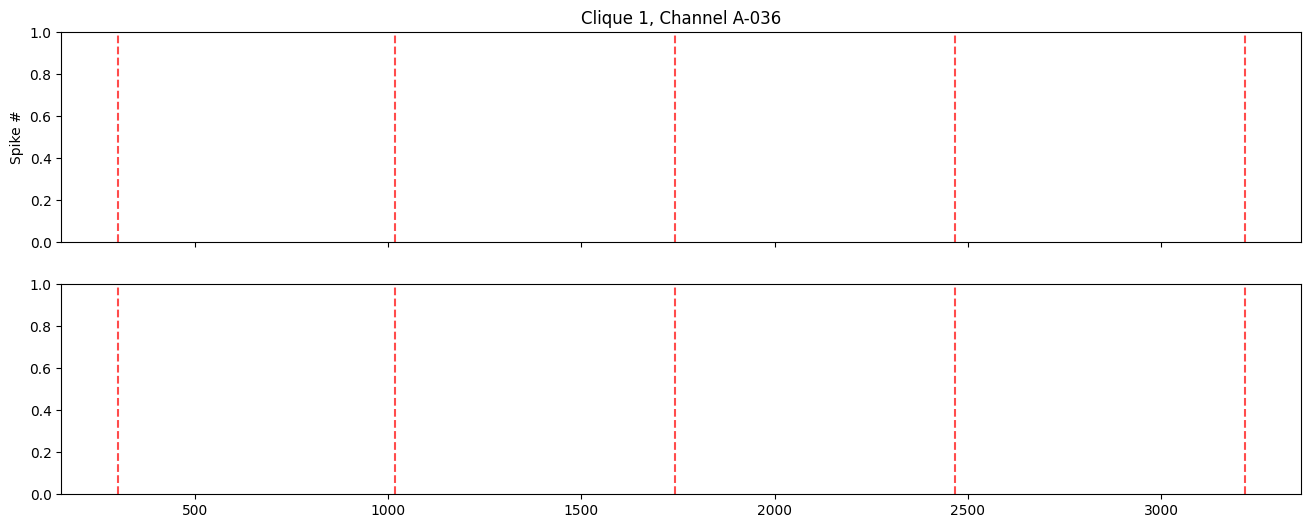

In [ ]:
# 绘制 trials 4477-4481 的 spike times 和 raster plot
# 时间窗: 从 trial 4477 刺激前 300ms 到 trial 4481 刺激后 600ms

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import pandas as pd

# 参数设置
fs = 10000  # 采样率
pre_time_ms = 300  # 刺激前时间
post_time_ms = 600  # 刺激后时间
pre_time_samples = int(pre_time_ms * fs / 1000)  # 3000 samples
post_time_samples = int(post_time_ms * fs / 1000)  # 6000 samples

# 选择 trials 4477-4481 (5个trials)
rec_params_selected = rec_params_raw.reset_index(drop=True).iloc[4478:4483].copy()
trial_ids = rec_params_selected['trial_ids'].values
stim_points = rec_params_selected['rec_codes_points_10000'].values

# 计算整个连续时间窗
window_start = int(stim_points[0]) - pre_time_samples  # 从 trial 4477 刺激前 300ms 开始
window_end = int(stim_points[-1]) + post_time_samples  # 到 trial 4481 刺激后 600ms 结束
total_window_samples = window_end - window_start
total_window_ms = total_window_samples / fs * 1000

print(f"选中 trials: {trial_ids}")
print(f"刺激时间点 (samples): {stim_points[0]} - {stim_points[-1]}")
print(f"时间窗: 从 trial 4477 前 300ms 到 trial 4481 后 600ms")
print(f"总时间窗长度: {total_window_samples} samples = {total_window_ms:.1f} ms")

# 获取 recording_segment 的起始时间点
segment_start_sample = int(rec_params_raw['rec_codes_points_10000'].iloc[0])

# 获取整个时间窗的 raw trace
recording_window = recording_f.frame_slice(start_frame=window_start, end_frame=window_end)

# 遍历所有 cliques
output_folder = '/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/'

for clique in cliques:
    clique_id = clique.clique_id
    print(f"\n处理 Clique {clique_id}...")
    
    # 获取 clique 对应的 recording
    test_recording_clique = get_recording_clique(recording_window, clique)
    channel_ids = test_recording_clique.get_channel_ids()
    
    # 读取 gt_array
    gt_array_path = f'{output_folder}/clique_{clique_id}/gt_detect_array_all.csv'
    gt_array = pd.read_csv(gt_array_path)
    
    # 获取 clique 的 neuron info
    neuron_inf_path = f'{output_folder}/clique_{clique_id}/neuron_inf_all.pickle'
    with open(neuron_inf_path, 'rb') as f:
        neuron_inf_dict = pickle.load(f)
    neuron_inf = neuron_inf_dict_to_dataframe(neuron_inf_dict)
    
    # 为每个 neuron 分配 channel
    neuron_channels = {}
    for _, row in neuron_inf.iterrows():
        neuron_channels[row['Neuron']] = row['extremum_channel']
    
    # 创建 PDF
    pdf_path = f'{output_folder}/clique_{clique_id}/raster_trace_trials_4477_4481.pdf'
    with PdfPages(pdf_path) as pdf:
        # 绘制每个 channel
        for ch_id in channel_ids:
            fig, (ax_raster, ax_trace) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
            
            # 获取该 channel 的 spikes (在整个时间窗内的)
            # gt_array 的 time 是相对于 recording_segment 的，所以需要加上 segment_start_sample
            gt_array_copy = gt_array.copy()
            gt_array_copy['absolute_time'] = gt_array_copy['time'] + segment_start_sample
            ch_spikes = gt_array_copy[(gt_array_copy['absolute_time'] >= window_start) & 
                                       (gt_array_copy['absolute_time'] < window_end)].copy()
            
            # 相对时间 (以 window_start 为 0 点，单位 ms)
            if len(ch_spikes) > 0:
                ch_spikes['time_ms'] = (ch_spikes['absolute_time'] - window_start) / fs * 1000
                # 分配 channel
                ch_spikes['channel'] = ch_spikes['unit_id'].map(neuron_channels)
                # 只保留当前 channel 的 spikes
                ch_spikes = ch_spikes[ch_spikes['channel'] == ch_id]
            
            for stim_point in stim_points:
                stim_time_ms = (stim_point - window_start) / fs * 1000
                ax_raster.axvline(x=stim_time_ms, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
                ax_trace.axvline(x=stim_time_ms, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Raster plot
            if len(ch_spikes) > 0:
                for i, (_, spike) in enumerate(ch_spikes.iterrows()):
                    ax_raster.vlines(spike['time_ms'], - 0.5, 0.5, colors='black', linewidth=1)
            ax_raster.set_ylabel('Spike #')
            ax_raster.set_title(f'Clique {clique_id}, Channel {ch_id}')
            
            # Raw trace
            trace = test_recording_clique.get_traces(channel_ids=[ch_id]).flatten()
            time_axis = np.arange(len(trace)) / fs * 1000  # 相对时间，以 window_start 为 0 点
            ax_trace.plot(time_axis, trace, 'b-', linewidth=0.5)
            ax_trace.set_ylabel('Amplitude (uV)')
            ax_trace.set_xlabel('Time (ms) relative to window start (trial 4477 stim - 300ms)')
            
            # 设置 x 轴范围
            ax_trace.set_xlim(0, total_window_ms)
            
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
    
    print(f"  PDF 已保存: {pdf_path}")

print(f"\n所有 cliques 的 raster 和 trace 绘制完成！")
print(f"时间窗总长度: {total_window_samples} samples = {total_window_ms:.1f} ms")

In [61]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import pandas as pd
import pickle
import torch

# 参数设置
fs = 10000
pre_time_ms = 300
post_time_ms = 600
pre_time_samples = int(pre_time_ms * fs / 1000)
post_time_samples = int(post_time_ms * fs / 1000)

# 选择 trials 4778-4782 (5个trials)
rec_params_selected = rec_params_raw.reset_index(drop=True).iloc[4778:4783].copy()
trial_ids = rec_params_selected['trial_ids'].values
stim_points = rec_params_selected['rec_codes_points_10000'].values

# 计算整个连续时间窗
window_start = int(stim_points[0]) - pre_time_samples
window_end = int(stim_points[-1]) + post_time_samples
total_window_samples = window_end - window_start
total_window_ms = total_window_samples / fs * 1000

print(f"选中 trials: {trial_ids}")
print(f"时间窗: {total_window_samples} samples = {total_window_ms:.1f} ms")

segment_start_sample = int(rec_params_raw['rec_codes_points_10000'].iloc[0])

target_channel = 'A-074'
target_clique_id = 0
output_folder = '/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/'

recording_window = recording_f.frame_slice(start_frame=window_start, end_frame=window_end)
test_recording_clique = get_recording_clique(recording_window, cliques[target_clique_id])
channel_ids = test_recording_clique.get_channel_ids()
channel_idx_map = {ch: i for i, ch in enumerate(channel_ids)}
target_ch_idx = channel_idx_map.get(target_channel)

print(f"Channel {target_channel} 在 clique_{target_clique_id} 中的索引: {target_ch_idx}")

gt_array_path = f'{output_folder}/clique_{target_clique_id}/gt_detect_array_all.csv'
gt_array = pd.read_csv(gt_array_path)

a074_unit_ids = gt_array[gt_array['extremum_channel'] == target_channel]['unit_id'].unique()
print(f"\n=== 映射关系分析 ===")
print(f"A-074 对应的 gt unit_ids: {a074_unit_ids}")

unit_channel_counts = gt_array.groupby(['unit_id', 'extremum_channel']).size().reset_index(name='count')
unit_to_channel = unit_channel_counts.loc[
    unit_channel_counts.groupby('unit_id')['count'].idxmax()
].set_index('unit_id')['extremum_channel'].to_dict()

model_save_dir = f'{output_folder}/clique_{target_clique_id}/model_1'
classification_mapping_path = f'{model_save_dir}/classification_mapping.pkl'
with open(classification_mapping_path, 'rb') as f:
    classification_mapping = pickle.load(f)


gt_array['absolute_time'] = gt_array['time'] + segment_start_sample
gt_spikes = gt_array[(gt_array['absolute_time'] >= window_start) & 
                      (gt_array['absolute_time'] < window_end)].copy()
gt_spikes['time_ms'] = (gt_spikes['absolute_time'] - window_start) / fs * 1000

gt_spikes_in_ch = gt_spikes[gt_spikes['unit_id'].isin(a074_unit_ids)].copy()

print(f"\nGT spikes 数量 (A-074): {len(gt_spikes_in_ch)}")

n_channels = test_recording_clique.get_num_channels()
samplepoints = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autosort_model = SimpleAutoSort(
    ch_num=n_channels,
    samplepoints=samplepoints,
    device=device,
    set_shank_id=classification_mapping['label_list'],
    save_dir=model_save_dir,
    pos_weight_noise=None,
    pos_weight_label=None
)
autosort_model.clsfier_noise.load_state_dict(torch.load(f'{model_save_dir}/multitask_single_wave_clsfier_noise_clsfier.pth', map_location=device))
autosort_model.clsfier_label.load_state_dict(torch.load(f'{model_save_dir}/multitask_single_wave_clsfier_label_clsfier.pth', map_location=device))
autosort_model.eval()

from utils_clique import (
    detect_spike,
    extract_waveforms)

trace0_car = recording_window.get_traces(channel_ids = ['A-074'])
spike_results = detect_spike(trace0_car)
predicted_spike = np.where(spike_results == 1)[0]
waveform = extract_waveforms(trace0_car, predicted_spike)

trace_full = test_recording_clique.get_traces()
waveform_full = extract_waveforms(trace_full, predicted_spike)

waveform_all = np.concatenate((waveform_full[0], waveform[0]), axis = 1)

new_column = np.full((279, 1, 30), fill_value=26, dtype=waveform_all.dtype)

waveform_expanded = np.concatenate([waveform_all, new_column], axis=1)  # (279, 34, 30)

results = autosort_model.clsfier_noise(torch.Tensor(waveform_expanded).to('cuda'))
noise_pred = torch.argmax(results, dim=1)

predicted_spike = predicted_spike[np.where(noise_pred.cpu().numpy() == 1)[0]] +window_start - start_sample

选中 trials: [5078 5079 5080 5081 5082]
时间窗: 38583 samples = 3858.3 ms
Channel A-074 在 clique_0 中的索引: 26

=== 映射关系分析 ===
A-074 对应的 gt unit_ids: [81 82]

GT spikes 数量 (A-074): 130


Extracting waveforms: 100%|██████████| 30/30 [00:00<00:00, 20664.99it/s]


In [89]:
# 绘制 A-074 的 raw trace, GT raster, predicted raster 对齐图

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

print("=== 绘制 A-074 对齐图 ===\n")
fs = 10000  # 采样率
target_channel = 'A-074'

trace = recording_window.get_traces(channel_ids=[target_channel]).flatten()
trace_time_axis = np.arange(len(trace)) / fs * 1000  # 转换为 ms

window_length_samples = len(trace)
window_length_ms = window_length_samples / fs * 1000

print(f"时间窗长度: {window_length_samples} samples = {window_length_ms:.1f} ms")
print(f"GT spikes 数量: {len(gt_spikes)}")
print(f"Predicted spikes 数量: {len(predicted_spike)}")


output_folder = '/media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort/'
pdf_path = f'{output_folder}/A074_alignment_comparison.pdf'

with PdfPages(pdf_path) as pdf:
    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
    
    for stim_point in stim_points:
        stim_time_ms = (stim_point - window_start) / fs * 1000
        for ax in axes:
            ax.axvline(x=stim_time_ms, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    axes[0].plot(trace_time_axis, trace, 'b-', linewidth=0.5)
    axes[0].set_ylabel('Amplitude (uV)')
    axes[0].set_title(f'Raw Trace - Channel {target_channel}')

    gt_spikes = gt_spikes[gt_spikes['extremum_channel']== 'A-074']
    gt_spikes_ms = gt_spikes['time'] / fs * 1000 -window_start / 10 + start_sample/10
    for i, spike_time in enumerate(gt_spikes_ms):
        axes[1].vlines(spike_time, -0.5, 0.5, colors='black', linewidth=1)
    axes[1].axis("off")
    
    if len(predicted_spike) > 0:
        pred_spikes_ms = predicted_spike / fs * 1000 -window_start/10 + start_sample/10
        for i, spike_time in enumerate(pred_spikes_ms):
            axes[2].vlines(spike_time, - 0.5, 0.5, colors='green', linewidth=1)
    
    axes[2].set_xlim(0, window_length_ms)
    axes[2].axis("off")

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

print(f"\nPDF 已保存: {pdf_path}")

=== 绘制 A-074 对齐图 ===

时间窗长度: 38583 samples = 3858.3 ms
GT spikes 数量: 130
Predicted spikes 数量: 198

PDF 已保存: /media/ubuntu/sda/visual_generation/results/neuroscroll_260122/mountainsort//A074_alignment_comparison.pdf


In [72]:
window_start

37348095

In [78]:
gt_spikes['time'] / fs * 1000 -window_start/10 + start_sample/10

320070      46.5
320071      47.9
320075      65.8
320078     204.2
320083     263.0
           ...  
320520    3674.8
320521    3682.0
320523    3716.2
320526    3723.1
320527    3732.3
Name: time, Length: 130, dtype: float64